# Linear Regression Implementation from Scratch
:label:`sec_linear_scratch`

We are now ready to work through 
a fully functioning implementation 
of linear regression. 
In this section, 
(**we will implement the entire method from scratch,
including (i) the model; (ii) the loss function;
(iii) a minibatch stochastic gradient descent optimizer;
and (iv) the training function 
that stitches all of these pieces together.**)
Finally, we will run our synthetic data generator
from :numref:`sec_synthetic-regression-data`
and apply our model
on the resulting dataset. 
While modern deep learning frameworks 
can automate nearly all of this work,
implementing things from scratch is the only way
to make sure that you really know what you are doing.
Moreover, when it is time to customize models,
defining our own layers or loss functions,
understanding how things work under the hood will prove handy.
In this section, we will rely only 
on tensors and automatic differentiation.
Later, we will introduce a more concise implementation,
taking advantage of the bells and whistles of deep learning frameworks 
while retaining the structure of what follows below.


## Defining the Model

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

In [2]:
class LinearRegressionScratch(d2l.Module):  #@save
    """The linear regression model implemented from scratch."""
    def __init__(self, num_inputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

In [3]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

In [4]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

For optimization algorithm, we can take the closed-form directly for LR 

But the goal is to illustrate how to train more general NN, which requires the use of minibatch SGD

(Use some random batch drawn from dataset to estimate the loss with respect to paramteres, 

and update them in the direction to minimize the loss)

In [5]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr): # lr === learning_rate 
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

`configure_optimizers()` returns and instance of the `SGD` class

In [6]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

#### Training

This method is used when we want to modify the batch before using it 

Right now it appears identical

In [7]:
@d2l.add_to_class(d2l.Trainer)  #@save
def prepare_batch(self, batch):
    return batch

This method perfomrs one full training epoch (process of all the data examples once)

In [ ]:
@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train() # Tells the model it is training
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            # Main Idea is that we clip/rescale the vector when grad > some value c 
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

tensor([[ 1.9995],
        [-3.3989]], requires_grad=True)
tensor([4.1995], requires_grad=True)


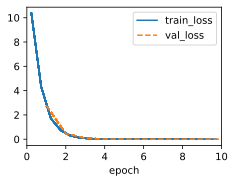

In [71]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2) # 1000 train and val examples by default 
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)
print(model.w)
print(model.b)

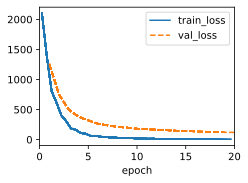

In [72]:
num_inputs = 4900
model = LinearRegressionScratch(num_inputs, lr=0.01)
data = d2l.SyntheticRegressionData(w=torch.randn(num_inputs, 1), b=2.3, num_train=5000, num_val=2000)
trainer = d2l.Trainer(max_epochs=20)
trainer.fit(model, data)

In [73]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([[-0.1559],
        [-0.1157],
        [-0.0266],
        ...,
        [-0.0154],
        [-0.2566],
        [ 0.0906]])
error in estimating b: tensor([0.4381])


## Exercises

1. What would happen if we were to initialize the weights to zero. Would the algorithm still work? What if we
   initialized the parameters with variance $1000$ rather than $0.01$?
1. Assume that you are [Georg Simon Ohm](https://en.wikipedia.org/wiki/Georg_Ohm) trying to come up
   with a model for resistance that relates voltage and current. Can you use automatic
   differentiation to learn the parameters of your model?
1. Can you use [Planck's Law](https://en.wikipedia.org/wiki/Planck%27s_law) to determine the temperature of an object
   using spectral energy density? For reference, the spectral density $B$ of radiation emanating from a black body is
   $B(\lambda, T) = \frac{2 hc^2}{\lambda^5} \cdot \left(\exp \frac{h c}{\lambda k T} - 1\right)^{-1}$. Here
   $\lambda$ is the wavelength, $T$ is the temperature, $c$ is the speed of light, $h$ is Planck's constant, and $k$ is the
   Boltzmann constant. You measure the energy for different wavelengths $\lambda$ and you now need to fit the spectral
   density curve to Planck's law.
1. What are the problems you might encounter if you wanted to compute the second derivatives of the loss? How would
   you fix them?
1. Why is the `reshape` method needed in the `loss` function?
1. Experiment using different learning rates to find out how quickly the loss function value drops. Can you reduce the
   error by increasing the number of epochs of training?
1. If the number of examples cannot be divided by the batch size, what happens to `data_iter` at the end of an epoch?
1. Try implementing a different loss function, such as the absolute value loss `(y_hat - d2l.reshape(y, y_hat.shape)).abs().sum()`.
    1. Check what happens for regular data.
    1. Check whether there is a difference in behavior if you actively perturb some entries, such as $y_5 = 10000$, of $\mathbf{y}$.
    1. Can you think of a cheap solution for combining the best aspects of squared loss and absolute value loss?
       Hint: how can you avoid really large gradient values?
1. Why do we need to reshuffle the dataset? Can you design a case where a maliciously constructed dataset would break the optimization algorithm otherwise?

2. Simple version

In [74]:
I = torch.tensor([1., 2., 3., 4.])
V = torch.tensor([5.1, 9.9, 15.2, 19.8])

R = torch.tensor([1.0], requires_grad=True)
lr = 0.01

for _ in range(1000):
    V_hat = I * R
    loss = ((V_hat - V) ** 2).mean()

    loss.backward()

    with torch.no_grad():
        R -= lr * R.grad
        R.grad.zero_()

print(R)  # approximately 5 ohms

tensor([4.9900], requires_grad=True)


This section version

Learned resistance: tensor([[4.9628]], requires_grad=True)
Learned bias: tensor([0.0014], requires_grad=True)


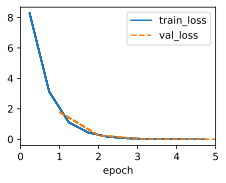

In [75]:
true_R = torch.tensor([5.0])

data = d2l.SyntheticRegressionData(
    w=true_R,
    b=0.0,
    noise=0.01
)

model = LinearRegressionScratch(
    num_inputs=1,
    lr=0.03
)

trainer = d2l.Trainer(max_epochs=5)
trainer.fit(model, data)

print("Learned resistance:", model.w)
print("Learned bias:", model.b)

3. We calculate for a certain T the values and try to approx with that

We get using the formula:

$$
x_i = \frac{hc}{\lambda_i k},
\qquad
y_i = \log\left(1 + \frac{2hc^2}{\lambda_i^5 B_i}\right).
$$

With:

$$
y_i = x_i \frac{1}{T}.
$$

Thus, the learned weight is:

$$
w = \frac{1}{T}
\quad\Longrightarrow\quad
T = \frac{1}{w}.
$$


We want to calculate the values for a certain T, we Take $T=66K$

In [93]:
import torch

torch.set_default_dtype(torch.float64)

# Exact physical constants
h = 6.62607015e-34       # Planck constant
c = 299792458.0          # Speed of light
k = 1.380649e-23         # Boltzmann constant

T_true = 66.0
num_values = 10000

# Wavelengths from 380 nm to 780 nm
wavelengths = torch.linspace(
    380e-9,
    780e-9,
    num_values
).reshape(-1, 1)

# Planck spectral density
exponent = h * c / (wavelengths * k * T_true)

B = (
    2 * h * c**2 / wavelengths**5
) / torch.expm1(exponent)

# Transform Planck's law into y = x(1/T)
X = h * c / (wavelengths * k)

y = torch.log1p(
    2 * h * c**2 / (wavelengths**5 * B)
)

pairs = torch.cat((X, y), dim=1)

print("    x_i                 y_i")
print(pairs)

# Verify y_i = x_i / T
print("\nMaximum error:", (y - X / T_true).abs().max())
print("True weight 1/T:", 1 / T_true)

    x_i                 y_i
tensor([[37862.5494,   573.6750],
        [37858.5639,   573.6146],
        [37854.5792,   573.5542],
        ...,
        [18447.7497,   279.5114],
        [18446.8035,   279.4970],
        [18445.8574,   279.4827]])

Maximum error: tensor(2.2737e-13)
True weight 1/T: 0.015151515151515152


Learned weight: 141.61727285842633
Learned bias: 37.441416802037224
Estimated temperature: 70.61285532589602


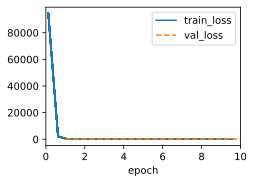

In [115]:
# Transforming our (X, y) pair into DataModule object
class PairData(d2l.DataModule):
    def __init__(self, pairs, batch_size=5, num_train=20):
        super().__init__()

        self.batch_size = batch_size
        self.num_train = num_train

        self.X = pairs[:, 0:1]
        self.y = pairs[:, 1:2]

    def get_dataloader(self, train):
        indices = (
            slice(0, self.num_train)
            if train
            else slice(self.num_train, None)
        )

        return self.get_tensorloader(
            (self.X, self.y),
            train,
            indices
        )


# Scale X down to reasonable values
# With 'lr=0.04' gradient produces enormous updates and it diverges
# We want to scale X back so it would reasonably converge
# If we decrease the learning rate to 1e-9 the bias and weights would update slowly
X_scale = 10_000.0
scaled_pairs = pairs.clone()
scaled_pairs[:, 0] /= X_scale

data = PairData(
    scaled_pairs,
    batch_size=5,
    num_train=20
)

model = LinearRegressionScratch(num_inputs=1, lr=0.04)
trainer = d2l.Trainer(max_epochs=10)

trainer.fit(model, data)

learned_w = model.w.item()
estimated_T = X_scale / learned_w

print("Learned weight:", learned_w)
print("Learned bias:", model.b.item())
print("Estimated temperature:", estimated_T)

In [113]:
with torch.no_grad():
    print(f'error in estimating w: {abs(10_000.0/T_true - learned_w)}')
    print(f'error in estimating b: {abs(0 - model.b.item())}')

    print(f'error in estimating T: {abs(T_true - 10_000.0/learned_w)}')

error in estimating w: 9.900202358225329
error in estimating b: 37.446024855921415
error in estimating T: 4.6140139832187685


5. Experimented in last part

8. Taking:

In [133]:
@d2l.add_to_class(LinearRegressionScratch)
def loss(self, y_hat, y):
    y = y.reshape(y_hat.shape)
    return (y_hat - y).abs().sum()

For comparaison:

In [129]:
@d2l.add_to_class(LinearRegressionScratch)
def loss(self, y_hat, y):
    y = y.reshape(y_hat.shape)
    l = (y_hat - y) ** 2 / 2
    return l.mean()

Learned weights: tensor([ 1.9265, -3.4147], grad_fn=<ReshapeAliasBackward0>)
Learned bias: tensor([4.1800], requires_grad=True)


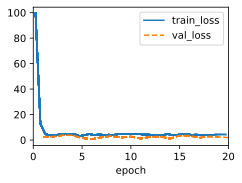

In [134]:
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2

data = d2l.SyntheticRegressionData(
    w=true_w,
    b=true_b,
    noise=0.01
)

# Smaller lr because loss uses sum(), not mean()
model = LinearRegressionScratch(num_inputs=2, lr=0.01)
trainer = d2l.Trainer(max_epochs=20)

trainer.fit(model, data)

print("Learned weights:", model.w.reshape(-1))
print("Learned bias:", model.b)

**A. Regular data:**  
Absolute loss works, but convergence is less smooth than squared loss.

**B. With $y_5=10000$:**  
Squared loss is dominated by the outlier since its gradient grows with the error. Absolute loss is more robust because its gradient is only $\pm1$.

**C. Cheap solution:**  
Use Huber loss:

$$
L(r)=
\begin{cases}
\frac12r^2, & |r|\leq\delta,\\
\delta(|r|-\frac12\delta), & |r|>\delta.
\end{cases}
$$

It uses squared loss for small errors and absolute loss for large errors.

Here we approximate $|r| \approx \sqrt{r^2 + \delta^2}$